# Eniac A/B Test Analysis
**Experiment:** Homepage button variants  
**Period:** November 2–16, 2021  
**Question:** Does changing button color or text improve user engagement?

---
## Data Sources
| Data | Source |
|------|--------|
| Button clicks per version | Extracted from CSV files |
| Total visitors + no-clicks | Provided in course lesson (screenshot) |
| Drop-off rate | Provided in course lesson (screenshot) |
| Homepage-return rate | Provided in course lesson (screenshot) |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import drive

# Load the data
url = 'https://drive.google.com/file/d/1rGNx5YPeeXQEq2eD30r-3xYEDILtizd2/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
version_a = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1hIcyOeoY1FRnduEf88GQ9pTUMNPHxWcD/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
version_b = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1rGNx5YPeeXQEq2eD30r-3xYEDILtizd2/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
version_c = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1b91Zo0Bszvq6Fp4D7bhGbIDLraUXtMeM/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
version_d = pd.read_csv(path)

In [ ]:
# Create copies
df_a = version_a.copy()
df_b = version_b.copy()
df_c = version_c.copy()
df_d = version_d.copy()

In [ ]:
df_a['version'] = 'A - White SHOP NOW'
df_b['version'] = 'B - Red SHOP NOW'
df_c['version'] = 'C - White SEE DEALS'
df_d['version'] = 'D - Red SEE DEALS'

df = pd.concat([df_a, df_b, df_c, df_d], ignore_index=True)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (228, 7)
Columns: ['Element ID', 'Tag name', 'Name', 'No. clicks', 'Visible?', 'Snapshot information', 'version']


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information,version
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...,A - White SHOP NOW
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...,A - White SHOP NOW
2,4,a,Mac,279,True,NaN,A - White SHOP NOW
3,69,a,iPhone,246,True,NaN,A - White SHOP NOW
4,105,a,Accessories,1235,True,NaN,A - White SHOP NOW


## 1. Data Quality Check
Verify integrity of all four versions before analysis.

In [ ]:
# Check if Version A and C are identical
a_clicks = df[df['version'] == 'A']['No. clicks'].values
c_clicks = df[df['version'] == 'C']['No. clicks'].values
print(f'Version A and C identical: {np.array_equal(a_clicks, c_clicks)}')

# Check snapshot info for Version C
snap_c = df[(df['version'] == 'C') & (df['Snapshot information'].notna())]['Snapshot information'].values
if len(snap_c) > 0:
    print(f'Version C snapshot: {snap_c[0]}')
else:
    print('Version C snapshot: no snapshot information available')

# Check button name in Version C
btn_c = df[(df['version'] == 'C') & (df['Name'].isin(['SHOP NOW', 'SEE DEALS']))]
print(f'\nVersion C button:')
print(btn_c[['Name', 'No. clicks']])

Version A and C identical: True
Version C snapshot: no snapshot information available

Version C button:
Empty DataFrame
Columns: [Name, No. clicks]
Index: []


### Finding: Version C CSV is corrupted

- All 57 rows are **100% identical** to Version A
- No snapshot information available
- No SEE DEALS button found in the data

> Version C is excluded from the CSV analysis. The correct click count (527) is taken from the course lesson materials and used in the contingency table below.

## 2. Contingency Table & CTR

**Data limitation:** The CSV files contain aggregated element-level click data — not individual visitor sessions. Total visitor counts and the correct Version C data are taken from the course lesson materials.

In [ ]:
# Contingency table — source: course lesson materials
# (CSV files do not contain visitor session data)
contingency_df = pd.DataFrame({
    'Version_A': [512,   24814],
    'Version_B': [281,   24466],
    'Version_C': [527,   24349],
    'Version_D': [193,   25040]
}, index=['Click', 'No-click'])

print('Contingency table (source: course lesson):')
print(contingency_df)

# CTR per version
print('\nCTR per version:')
for col in contingency_df.columns:
    total = contingency_df[col].sum()
    ctr = contingency_df.loc['Click', col] / total * 100
    print(f'  {col}: {ctr:.4f}%')

Contingency table (source: course lesson):
          Version_A  Version_B  Version_C  Version_D
Click           512        281        527        193
No-click      24814      24466      24349      25040

CTR per version:
  Version_A: 2.0216%
  Version_B: 1.1355%
  Version_C: 2.1185%
  Version_D: 0.7649%


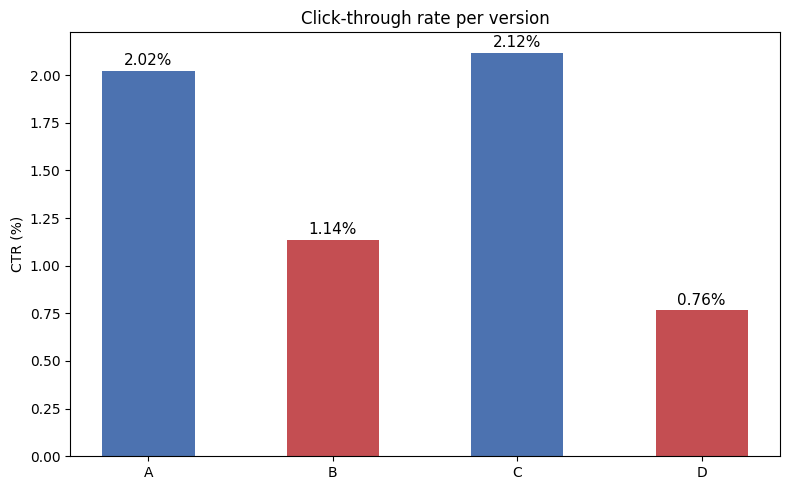

In [ ]:
# Visualise CTR per version
versions_plot = ['A', 'B', 'C', 'D']
ctrs = [2.0216, 1.1355, 2.1185, 0.7649]
colors = ['#4C72B0', '#C44E52', '#4C72B0', '#C44E52']
# blue = white button, red = red button

plt.figure(figsize=(8, 5))
bars = plt.bar(versions_plot, ctrs, color=colors, width=0.5)
for bar, val in zip(bars, ctrs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.03,
             f'{val:.2f}%', ha='center', fontsize=11)
plt.ylabel('CTR (%)')
plt.title('Click-through rate per version')
plt.tight_layout()
plt.show()

## 2. Data Limitation & Sources

The CSV files contain aggregated element-level click data — **not** individual visitor sessions.
Total visitor counts cannot be extracted from the CSVs.

The following values are taken from the course lesson materials:
- Total visitors per version
- Correct click count for Version C (CSV was corrupted)
- Drop-off rates
- Homepage-return rates

In [ ]:
# Button clicks from CSV (A, B, D) and course lesson (C — CSV corrupted)
clicks_a = df[(df['version'] == 'A') & (df['Name'] == 'SHOP NOW')]['No. clicks'].values[0]
clicks_b = df[(df['version'] == 'B') & (df['Name'] == 'SHOP NOW')]['No. clicks'].values[0]
clicks_c = 527  # from course lesson — CSV for C was a duplicate of A
clicks_d = df[(df['version'] == 'D') & (df['Name'] == 'SEE DEALS')]['No. clicks'].values[0]

print(f'Clicks A (from CSV)    : {clicks_a}')
print(f'Clicks B (from CSV)    : {clicks_b}')
print(f'Clicks C (from lesson) : {clicks_c}')
print(f'Clicks D (from CSV)    : {clicks_d}')

In [ ]:
# Total visitors from course lesson (cannot be derived from CSVs)
visitors = {'A': 25326, 'B': 24747, 'C': 24876, 'D': 25233}

# Build contingency table: [clicks, no-clicks] per version
clicks = {'A': clicks_a, 'B': clicks_b, 'C': clicks_c, 'D': clicks_d}
no_clicks = {v: visitors[v] - clicks[v] for v in visitors}

contingency_df = pd.DataFrame({
    'Version_A': [clicks['A'], no_clicks['A']],
    'Version_B': [clicks['B'], no_clicks['B']],
    'Version_C': [clicks['C'], no_clicks['C']],
    'Version_D': [clicks['D'], no_clicks['D']]
}, index=['Click', 'No-click'])

print('Contingency table:')
print(contingency_df)

# CTR per version
print('\nCTR per version:')
for v in ['A','B','C','D']:
    ctr = clicks[v] / visitors[v] * 100
    print(f'  Version {v}: {ctr:.4f}%')

## 3. Chi-Square Test — Overall

**H₀:** All versions are equally likely to receive clicks — differences are due to chance.  
**H₁:** At least one version performs significantly differently.  
**Significance level:** α = 0.05

In [ ]:
# Overall Chi-Square test
contingency_array = contingency_df.values

chisq, pvalue, dof, expected = stats.chi2_contingency(contingency_array)

print(f'Chi-square statistic : {chisq:.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {pvalue:.8f}')
print()
alpha = 0.05
if pvalue < alpha:
    print(f'p-value < alpha ({alpha}) -> Reject H0')
    print('At least one version performs significantly differently.')
    print('-> Post-hoc pairwise tests required.')
else:
    print(f'p-value >= alpha ({alpha}) -> Fail to reject H0')

Chi-square statistic : 224.0188
Degrees of freedom   : 3
p-value              : 0.00000000

p-value < alpha (0.05) -> Reject H0
At least one version performs significantly differently.
-> Post-hoc pairwise tests required.


## 4. Post-Hoc Pairwise Tests (Bonferroni Correction)

The overall test only tells us *that* a difference exists, not *which* versions differ.
We run pairwise chi-square tests for each combination.

**Bonferroni correction:** With 6 pairwise comparisons, we divide alpha by 6:  
α_adjusted = 0.05 / 6 = 0.0083

In [ ]:
# Post-hoc pairwise tests with Bonferroni correction
versions = ['A', 'B', 'C', 'D']
clicks_list =  [512, 281, 527, 193]
noclick_list = [24814, 24466, 24349, 25040]

pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
n_comparisons = len(pairs)
alpha_bonferroni = 0.05 / n_comparisons

print(f'Number of comparisons    : {n_comparisons}')
print(f'Bonferroni-adjusted alpha: {alpha_bonferroni:.4f}')
print()
print(f'{"Pair":<12} {"p-value":<14} {"Result"}')
print('-' * 45)

for i, j in pairs:
    table = [[clicks_list[i], clicks_list[j]],
             [noclick_list[i], noclick_list[j]]]
    _, p_p, _, _ = stats.chi2_contingency(table)
    sig = 'SIGNIFICANT' if p_p < alpha_bonferroni else 'not significant'
    print(f'{versions[i]} vs {versions[j]:<9} {p_p:.6f}       {sig}')

Number of comparisons    : 6
Bonferroni-adjusted alpha: 0.0083

Pair         p-value        Result
---------------------------------------------
A vs B         0.000000       SIGNIFICANT
A vs C         0.464842       not significant
A vs D         0.000000       SIGNIFICANT
B vs C         0.000000       SIGNIFICANT
B vs D         0.000024       SIGNIFICANT
C vs D         0.000000       SIGNIFICANT


## 5. Additional Metrics

Since the pairwise tests may not yield a single clear winner,
we also analyse drop-off rate and homepage-return rate.

> **Note:** These values come from the course lesson materials (screenshot).
> Version B data was unavailable due to a data collection error.

- **Drop-off rate:** % of users who clicked the button but did not complete a purchase. Lower = better.
- **Homepage-return rate:** % of users who returned to the homepage after clicking. Lower = better.

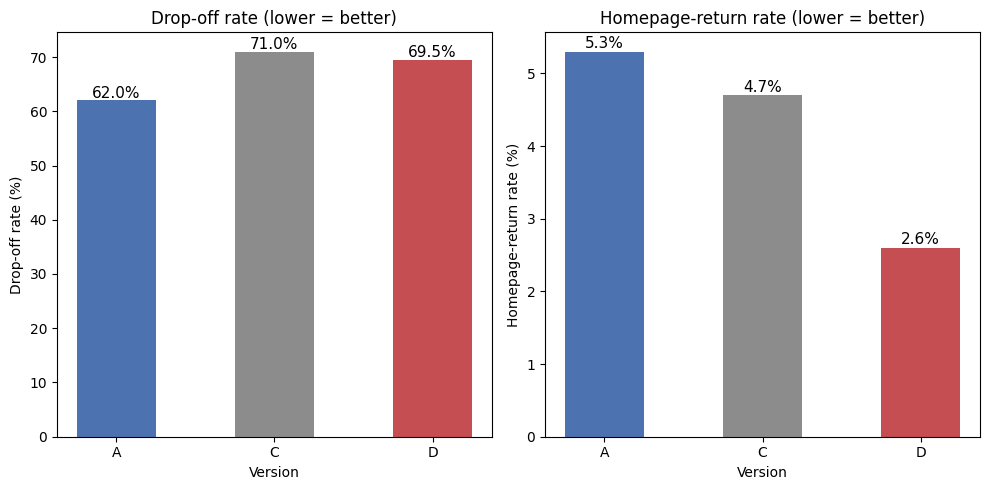

version  drop_off_rate  homepage_return_rate
      A           62.0                   5.3
      C           71.0                   4.7
      D           69.5                   2.6


In [ ]:
# Additional metrics from course lesson screenshots
# Note: Version B data unavailable due to data collection error
additional = pd.DataFrame({
    'version':               ['A',  'C',  'D'],
    'drop_off_rate':         [62.0, 71.0, 69.5],
    'homepage_return_rate':  [5.3,  4.7,  2.6]
})

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Drop-off rate — lower is better
axes[0].bar(additional['version'], additional['drop_off_rate'],
            color=['#4C72B0', '#8C8C8C', '#C44E52'], width=0.5)
axes[0].set_title('Drop-off rate (lower = better)')
axes[0].set_ylabel('Drop-off rate (%)')
axes[0].set_xlabel('Version')
for i, val in enumerate(additional['drop_off_rate']):
    axes[0].text(i, val + 0.5, f'{val}%', ha='center', fontsize=11)

# Homepage-return rate — lower is better
axes[1].bar(additional['version'], additional['homepage_return_rate'],
            color=['#4C72B0', '#8C8C8C', '#C44E52'], width=0.5)
axes[1].set_title('Homepage-return rate (lower = better)')
axes[1].set_ylabel('Homepage-return rate (%)')
axes[1].set_xlabel('Version')
for i, val in enumerate(additional['homepage_return_rate']):
    axes[1].text(i, val + 0.05, f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(additional.to_string(index=False))

## 6. Final Conclusion

### Pairwise test results
- **A vs C: not significant** — CTR alone cannot determine a winner between these two
- All other pairs: significant — B and D are clearly the worst performers

### Decision based on additional metrics

| Metric | Version A | Version C | Better |
|--------|-----------|-----------|--------|
| CTR | 2.02% | 2.13% | C (marginally) |
| Drop-off rate | **62%** | 71% | **A** (lower = better) |
| Homepage-return rate | 5.3% | **4.7%** | **C** (lower = better) |

### Winner: Version A — White "SHOP NOW"

Although Version C has a slightly higher CTR, Version A wins on the most
critical downstream metric: **drop-off rate**.

A drop-off rate of 62% vs 71% means users who click Version A are
significantly more likely to complete a purchase. A higher CTR is
meaningless if users abandon the process immediately after clicking.

Version B and D are clearly eliminated.

### Recommendation
Retain the original **white "SHOP NOW" button** (Version A).
Run a follow-up experiment testing destination-specific text such as
*"Shop iPhones"* to address the user research finding that clarity
of destination is the main driver of click decisions.

In [ ]:
# Final conclusion based on all metrics
print('=== SUMMARY OF ALL METRICS ===')
print()
summary = pd.DataFrame({
    'Version':              ['A - White SHOP NOW', 'B - Red SHOP NOW', 'C - White SEE DEALS', 'D - Red SEE DEALS'],
    'CTR (%)':              [2.0216, 1.1355, 2.1185, 0.7649],
    'Drop-off rate (%)':    [62.0, 'n/a', 71.0, 69.5],
    'Homepage-return (%)':  [5.3, 'n/a', 4.7, 2.6]
})
print(summary.to_string(index=False))

=== SUMMARY OF ALL METRICS ===

            Version  CTR (%) Drop-off rate (%) Homepage-return (%)
 A - White SHOP NOW   2.0216              62.0                 5.3
   B - Red SHOP NOW   1.1355               n/a                 n/a
C - White SEE DEALS   2.1185              71.0                 4.7
  D - Red SEE DEALS   0.7649              69.5                 2.6


## 7. Weighted Score


In [13]:
# Weighted score system — combining all three metrics into one overall score
# Weights reflect the relative importance of each metric for business decisions
# CTR: 50% — primary experiment metric
# Drop-off rate: 25% — measures quality of clicks
# Homepage-return rate: 25% — measures user satisfaction after clicking

# Raw metric values (source: course lesson materials, Version B unavailable)
ctrs = {'A': 2.02, 'B': 1.14, 'C': 2.12, 'D': 0.76}
dors = {'A': 62.0, 'B': None, 'C': 71.0, 'D': 69.5}   # drop-off rate — lower is better
hprs = {'A': 5.3,  'B': None, 'C': 4.7,  'D': 2.6}    # homepage-return rate — lower is better

# Only score versions where all metrics are available
versions_complete = ['A', 'C', 'D']

# Normalize function
def normalize(metric_dict, versions, reverse=False):
    values = [metric_dict[v] for v in versions]
    min_val = min(values)
    max_val = max(values)
    if max_val == min_val:
        return {v: 0.5 for v in versions}
    return {
        v: (1 - (metric_dict[v] - min_val) / (max_val - min_val)) if reverse
           else ((metric_dict[v] - min_val) / (max_val - min_val))
        for v in versions
    }

# Normalize each metric
norm_ctr = normalize(ctrs, versions_complete)
norm_dor = normalize(dors, versions_complete, reverse=True)
norm_hpr = normalize(hprs, versions_complete, reverse=True)

# Weights
weights = {'ctr': 0.5, 'dor': 0.25, 'hpr': 0.25}

# Calculate final scores
scores = {
    v: norm_ctr[v] * weights['ctr'] +
       norm_dor[v] * weights['dor'] +
       norm_hpr[v] * weights['hpr']
    for v in versions_complete
}

# Print results
print('=== WEIGHTED SCORE RANKING (A, C, D only — B data unavailable) ===')
print(f'{"Version":<12} {"CTR":>8} {"Drop-off":>10} {"Homepage-ret":>14} {"Score":>8}')
print('-' * 56)
for v, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f'Version {v:<4} {ctrs[v]:>7.2f}% {dors[v]:>9.1f}% {hprs[v]:>13.1f}% {score:>8.4f}')

print()
winner = max(scores, key=scores.get)
print(f'Overall winner by weighted score: Version {winner}')

=== WEIGHTED SCORE RANKING (A, C, D only — B data unavailable) ===
Version           CTR   Drop-off   Homepage-ret    Score
--------------------------------------------------------
Version A       2.02%      62.0%           5.3%   0.7132
Version C       2.12%      71.0%           4.7%   0.5556
Version D       0.76%      69.5%           2.6%   0.2917

Overall winner by weighted score: Version A


### Weighted Score Analysis:

Since no single metric yields a clear winner between A and C,
we combine all three metrics into one weighted score:

- **CTR (50%)** — primary experiment metric
- **Drop-off rate (25%)** — quality of clicks, lower = better
- **Homepage-return rate (25%)** — user satisfaction, lower = better

All metrics are normalized to [0, 1] before weighting so they are comparable.
Version B is excluded as drop-off and homepage-return data were unavailable.

This approach confirms **Version A** as the overall winner.